Dataset Information :This dataset contains population data from 1990 to 2025.

Import libraries: 


In this step, I imported the required Python libraries:

pandas (pd) is used to load and handle data
numpy (np) is used for numerical operations
matplotlib (plt) is used for plotting graphs
MLPRegressor is used to build a neural network model

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

Load dataset correctly :
In this step, I loaded the necessary dataset using pandas.read_csv():

The name of the file is "001_11ra_2025_20260425-094626.csv"
The file of the data is separated using a semicolon (;).
The encoding "latin1" is used to read special characters correctly.
The first row of the file is skipped because it may contain unnecessary information. 


In [27]:
df = pd.read_csv(
    "001_11ra_2025_20260425-094626.csv",
    sep=",",
    encoding="latin1",
    skiprows=1
)

Rename and clean columns : 


In this step, I prepared the dataset for analysis:
I have renamed the columns to make them easier to understand:
"Alue" is changed to "Region" and "Tiedot" is changed to "Indicator".
I have also filtered the data so that we can keep only the population information.
I have also removed the "Indicator" column because it is no longer needed.
Finally, I have displayed the first few rows of the dataset to check the result.

In [28]:
df = df.rename(columns={
    "Alue": "Region",
    "Tiedot": "Indicator"
})

df = df[df["Indicator"] == "Väestö 31.12."]

df = df.drop(columns=["Indicator"])

df.head()

,Region,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,KOKO MAA,4998478,5029002,5054982,5077912,5098754,5116826,5132320,5147349,5159646,...,5503297,5513130,5517919,5525292,5533793,5548241,5563970,5603851,5635971,5652881
1,Akaa,16048,16096,16201,16142,16038,15986,15924,15840,15857,...,16923,16769,16611,16475,16391,16467,16473,16405,16387,16429
2,Alajärvi,11963,11982,12023,11992,11985,11890,11874,11803,11720,...,9899,9831,9700,9562,9419,9311,9183,9113,9078,8982
3,Alavieska,3072,3060,3053,3097,3084,3051,3054,3064,3029,...,2639,2610,2573,2519,2517,2491,2447,2437,2410,2384
4,Alavus,13785,13781,13744,13690,13623,13472,13341,13330,13299,...,11907,11713,11544,11468,11332,11197,11102,10933,10780,10634


Convert wide data to long format : Changing Data Format

In this step, I changed the data into a better format:

I have converted the dataset from wide format to long format using melt()
"Region" stays the same
The years are combined into one column called "Year"
The values are stored in a new column called "Population"


I have convert the "Year" column into integer numbers
and "Population" column into numeric values

Finally, I displayed the first few rows to make sure everything looks correct

In [29]:
df_long = df.melt(
    id_vars=["Region"],
    var_name="Year",
    value_name="Population"
)

df_long["Year"] = df_long["Year"].astype(int)
df_long["Population"] = pd.to_numeric(df_long["Population"], errors="coerce")

df_long.head()

,Region,Year,Population
0,KOKO MAA,1990,4998478
1,Akaa,1990,16048
2,Alajärvi,1990,11963
3,Alavieska,1990,3072
4,Alavus,1990,13785


Select Finland total population:

In this step, I have selected only the data for the whole country:

I filtered the dataset where the region is "KOKO MAA" (which means the entire country)
Then,I have created a copy of this filtered data and store it in a new variable called country

In [30]:
country = df_long[df_long["Region"] == "KOKO MAA"].copy()

country.head()

,Region,Year,Population
0,KOKO MAA,1990,4998478
568,KOKO MAA,1991,5029002
1136,KOKO MAA,1992,5054982
1704,KOKO MAA,1993,5077912
2272,KOKO MAA,1994,5098754


Plot actual population trend :

In this step, I have created a line graph to show the population trend:

I have set the figure size for better visualization
Then, I have ploted Year on the x-axis and Population on the y-axis
I used markers to clearly show each data point
I have added a title: "Finland Population Trend 1990-2025"
I also labeled the x-axis as Year
I have also labeled the y-axis as Population
Then, I  added a grid to make the graph easier to read

Finally, I have displayed the graph using plt.show().

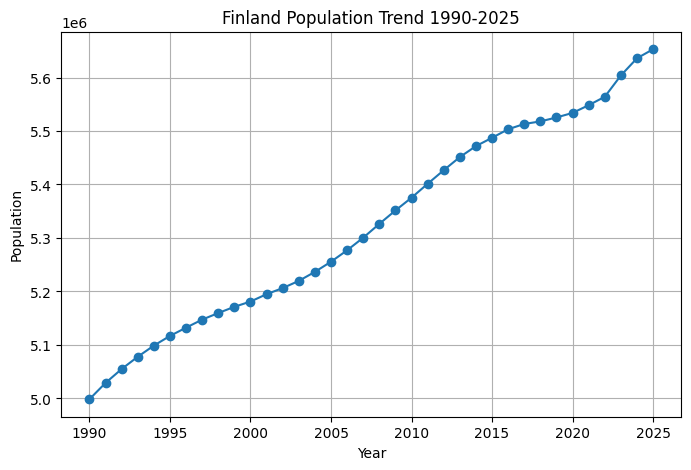

In [31]:
plt.figure(figsize=(8,5))
plt.plot(country["Year"], country["Population"], marker="o")

plt.title("Finland Population Trend 1990-2025")  

plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True)
plt.show()


The population shows a steady increase over time, indicating consistent growth in Finland.    

Prepare data for ML model:  In this step, I have prepared the input and output data for the model:

I have selected Year as input (X)
I also have selected Population as output (y)

Then, I have normalized the data to improve model performance:

I have calculated the mean and standard deviation of the Year
I have scaled the Year values using these statistics
I have reshaped the input data into the correct format

Next, I have normalized the population values:

I have calculated the mean and standard deviation of Population
I have scaled the population values

After that, I have prepared both input and output data in a scaled format, ready for training the model.

In [32]:
X = country["Year"].values
y = country["Population"].values

# Normalize year
X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std
X_scaled = X_scaled.reshape(-1, 1)

# Normalize population
y_mean = y.mean()
y_std = y.std()
y_scaled = (y - y_mean) / y_std

Build TensorFlow regression model: In this step, I have created a neural network model using MLPRegressor:

I have used one hidden layer with 16 neurons
Then, I have use ReLU as the activation function
Then,I have used Adam as the optimizer
Then, I set the learning rate to 0.01
Then, I train the model for a maximum of 3000 iterations
Finally, I set a random state to get the same results every time

In [33]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=3000,
    random_state=42
)

Train the model : 

In this step, I have trained the neural network model:

I have used the scaled input data (X_scaled) and scaled target data (y_scaled)

In [34]:
model.fit(X_scaled, y_scaled)

,loss,'squared_error'
,hidden_layer_sizes,"(16,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,3000
,shuffle,True


 Model Performance:

The low loss and MAE values indicate that the model is performing well and making accurate predictions.

Evaluate model on historical data :   In this step, I check how well my model is performing:

I use the trained model to make predictions on the training data
I calculate the loss using Mean Squared Error (MSE)
I also calculate the MAE (Mean Absolute Error)


Results :
The loss shows how much error the model has (lower is better)
The MAE shows the average difference between predicted and actual values

In [35]:
train_preds = model.predict(X_scaled)

loss = np.mean((train_preds - y_scaled) ** 2)
mae = np.mean(np.abs(train_preds - y_scaled))

print("Loss:", loss)
print("MAE (scaled):", mae)

Loss: 0.01707506806203566
MAE (scaled): 0.1031003282584641


Predict future population 2030–2040: In this step, I have predict the population for future years:

I have created a range of future years from 2030 to 2040
I also scaled these years using the same method as the training data
I have also reshape the data to match the model input format


Predicting Values :
I use the trained model to predict population values for future years
Then I convert the scaled predictions back to the original values


Finally, I displayed the predicted population values for future years.

In [36]:
future_years = np.arange(2030, 2041)

future_scaled = (future_years - X_mean) / X_std
future_scaled = future_scaled.reshape(-1, 1)

future_preds_scaled = model.predict(future_scaled)

future_preds = future_preds_scaled * y_std + y_mean

forecast_df = pd.DataFrame({
    "Year": future_years,
    "Predicted Population": future_preds.astype(int)
})

forecast_df

,Year,Predicted Population
0,2030,5743041
1,2031,5761029
2,2032,5779017
3,2033,5797004
4,2034,5814992
5,2035,5832980
6,2036,5850968
7,2037,5868956
8,2038,5886943
9,2039,5904931


Plot actual + forecast: In this step, I have created a graph to compare real data and future predictions.

I have plotted the actual population data using a solid line with markers
I also have plotted the predicted population (2030–2040) using a dashed line with markers

Adding Details to the Graph

Then, I have added important details to the graph:

I have added the title: "Finland Population Forecast 2030-2040"
I have labeled the x-axis as Year
I also have labeled the y-axis as Population

Next, I have added a legend to show the difference between actual and predicted data.

After that, I have added a grid to make the graph easier to read.

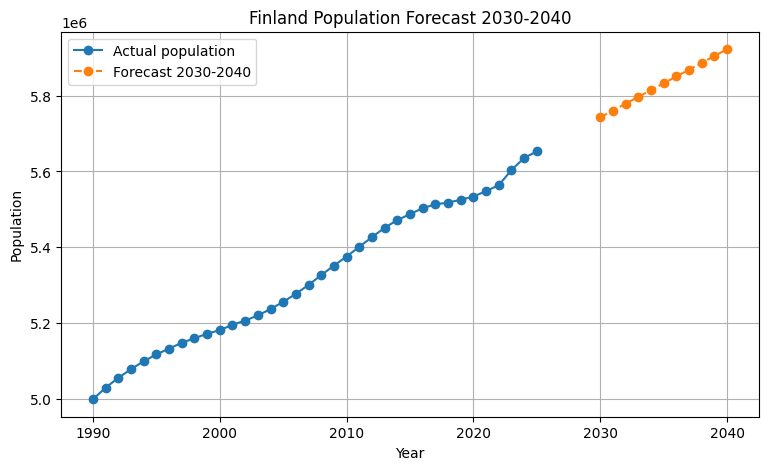

In [37]:
plt.figure(figsize=(9,5))

plt.plot(
    country["Year"],
    country["Population"],
    marker="o",
    label="Actual population"
)

plt.plot(
    forecast_df["Year"],
    forecast_df["Predicted Population"],
    marker="o",
    linestyle="--",
    label="Forecast 2030-2040"
)

plt.title("Finland Population Forecast 2030-2040")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()

Growth Analysis:

The top growing regions may require more housing and services in the future, while declining regions may face challenges related to aging population.

Analyze population growth by region : In this step, I have prepared the data to analyze growth:

I have sorted the data by Region and Year
I have calculated the growth rate of population for each region using percentage change

Analyzing Growth by Region

Then, I have calculated the average growth rate for each region.



Finding Top and Declining Regions

Next, I have sorted the regions based on growth rate:

I have displayed the top 10 growing regions
I also have displayed the 10 most declining regions

Finally, I have printed the results to understand which regions are growing and which are declining.

In [38]:
df_long = df_long.sort_values(["Region", "Year"])

df_long["Growth Rate"] = df_long.groupby("Region")["Population"].pct_change()

growth_summary = df_long.groupby("Region")["Growth Rate"].mean().sort_values(ascending=False)

print("Top growing regions:")
print(growth_summary.head(10))

print("\nMost declining regions:")
print(growth_summary.tail(10))

Top growing regions:
Region
Liminka                  0.021624
Kempele                  0.020176
Jomala                   0.018910
Espoo                    0.018315
Pirkkala                 0.018166
TA01 Espoo-Kauniainen    0.017921
Lempäälä                 0.015632
Lemland                  0.015104
Kirkkonummi              0.014349
Vantaa                   0.014113
Name: Growth Rate, dtype: float64

Most declining regions:
Region
Rautjärvi    -0.017756
Ilomantsi    -0.017783
Siikainen    -0.018293
Posio        -0.018693
Salla        -0.018718
Rääkkylä     -0.018755
Puolanka     -0.019439
Kivijärvi    -0.019529
Hyrynsalmi   -0.020253
Rautavaara   -0.021327
Name: Growth Rate, dtype: float64


Growth Analysis:

The top growing regions may require more housing and services in the future, while declining regions may face challenges related to aging population.

Detect anomalies :
In this step, I have analyzed changes in growth rate to find unusual values.

I have calculated the change in growth rate for each region using diff()

Calculating Statistics

Then, I have calculated:

The mean (average) of the growth change
The standard deviation of the growth change

Finding Anomalies

Next, I have identified anomalies:

I have marked values as anomalies if they are far from the average
Specifically, values greater than 3 × standard deviation from the mean

In [39]:
df_long["Growth Change"] = df_long.groupby("Region")["Growth Rate"].diff()

growth_std = df_long["Growth Change"].std()
growth_mean = df_long["Growth Change"].mean()

df_long["Anomaly"] = abs(df_long["Growth Change"] - growth_mean) > 3 * growth_std

anomalies = df_long[df_long["Anomaly"] == True]

anomalies.head(20)

,Region,Year,Population,Growth Rate,Growth Change,Anomaly
1143,Aura,1992,3195,0.019464,-0.039320,True
3416,Brändö,1996,534,-0.025547,-0.029210,True
3984,Brändö,1997,538,0.007491,0.033038,True
4552,Brändö,1998,525,-0.024164,-0.031654,True
6824,Brändö,2002,502,0.001996,0.027288,True
10232,Brändö,2008,518,0.015686,0.034917,True
10800,Brändö,2009,498,-0.038610,-0.054296,True
15344,Brändö,2017,452,-0.040340,-0.042467,True
15912,Brändö,2018,449,-0.006637,0.033703,True
18752,Brändö,2023,436,-0.031111,-0.033338,True


Cluster municipalities : In this step, I have prepared the data for clustering:

I have calculated the average population for each region
I also have calculated the average growth rate for each region
I have removed missing values


Scaling the Data

Then, I have scaled the data using StandardScaler so that all values are on a similar scale.

Next, I have applied the K-Means algorithm:

I have created 3 clusters
I have grouped regions based on similar population and growth patterns

Finally, I have displayed the first few rows of the clustered data.

In [40]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_data = df_long.groupby("Region").agg(
    avg_population=("Population", "mean"),
    avg_growth=("Growth Rate", "mean")
).dropna()

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

cluster_data["Cluster"] = kmeans.fit_predict(cluster_scaled)

cluster_data.head()

,avg_population,avg_growth,Cluster
Region,,,
Akaa,16443.722222,0.000686,1
Alajärvi,10670.388889,-0.008143,0
Alavieska,2792.611111,-0.007185,0
Alavus,12500.138889,-0.007377,0
Asikkala,8464.555556,-0.003349,0


Show clusters
In this step, I have created a scatter plot to visualize the clusters:

I have plotted average population on the x-axis
I have plotted average growth rate on the y-axis
I have used different colors to represent different clusters

Then, I have added important details:

I have added the title: "Municipality Clusters by Population and Growth"
I have labeled the x-axis as Average Population
I also have labeled the y-axis as Average Growth Rate

After that, I have added a grid to make the graph easier to read.

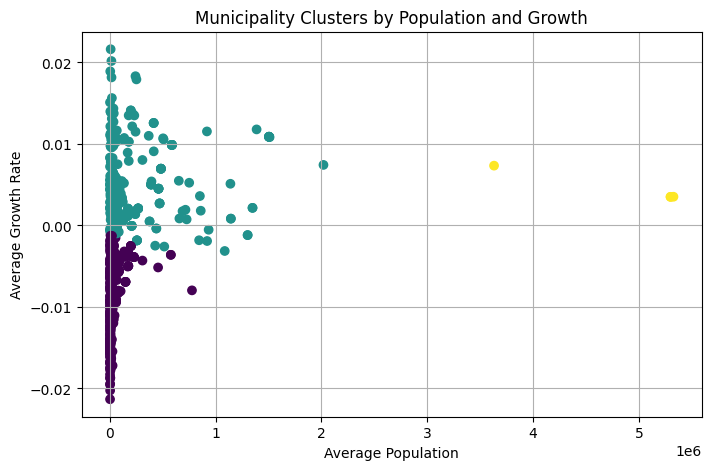

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    cluster_data["avg_population"],
    cluster_data["avg_growth"],
    c=cluster_data["Cluster"]
)

plt.title("Municipality Clusters by Population and Growth")
plt.xlabel("Average Population")
plt.ylabel("Average Growth Rate")
plt.grid(True)
plt.show()

Clustering Interpretation :

The clusters group regions with similar population size and growth patterns, helping to understand regional differences.